In [1]:
!pip install networkx transformers torch pandas matplotlib pyvis

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/8.3 MB ? eta -:--:--
   ------ --------------------------------- 1.3/8.3 MB 7.1 MB/s eta 0:00:01
   ---------------- ----------------------- 3.4/8.3 MB 8.4 MB/s eta 0:00:01
   --------------------------- ------------ 5.8/8.3 MB 9.7 MB/s eta 0:00:01
   ---------------------------------------- 8.3/8.3 MB 10.5 MB/s  0:00:00
   ---------------------------------------- 0.0/756.0 kB ? eta -:--:--
   ---------------------------------------- 756.0/756.0 kB 14.3 MB/s  0:00:00
   ---------------------------------------- 0.0/2.3 MB ? eta -:--:--
   ---------------------------------------- 2.3/2.3 MB 18.0 MB/s  0:00:00

   ----------- ---------------------------- 2/7 [fonttools]
   ----------- ---------------------------- 2/7 [fonttools]
   ----------- ---------------------------- 2/7 [fonttools]
   ----------- ---------------------------- 2/7 [fonttools]
   ----------- ---

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 25.3 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import torch
import pandas as pd
import networkx as nx
import json
import re
import os
from transformers import AutoTokenizer, AutoModelForTokenClassification, AutoModelForSequenceClassification
from collections import defaultdict
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

device = torch.device("cpu")

print("Libraries imported successfully!")
print(f"NetworkX version: {nx.__version__}")
print(f"Device: {device}")

Libraries imported successfully!
NetworkX version: 3.6.1
Device: cpu


In [5]:
import os

# Search for the NER model folder
search_paths = [
    r"D:\Climate_Intelligent_System\models",
    r"C:\Users\Sista",
    r"D:\Climate_Intelligent_System",
]

for search_path in search_paths:
    if os.path.exists(search_path):
        print(f"\nContents of {search_path}:")
        for item in os.listdir(search_path):
            print(f"  {item}")


Contents of D:\Climate_Intelligent_System\models:
  best_scibert_ner_v2.pt
  best_scibert_re.pt
  scibert_ner_climate_v2.zip
  scibert_re_climate

Contents of C:\Users\Sista:
  .amp
  .amplify
  .android
  .antigravity
  .aws
  .cache
  .config
  .cursor
  .docker
  .emulator_console_auth_token
  .gemini
  .gitconfig
  .gradle
  .ipython
  .jupyter
  .local
  .matplotlib
  .vscode
  .vscode-shared
  AppData
  Application Data
  Climate_Intelligent_System
  Contacts
  Cookies
  Desktop
  Documents
  Downloads
  Favorites
  IntelGraphicsProfiles
  label-studio-data
  Links
  Local Settings
  ls_env
  Music
  My Documents
  NetHood
  NTUSER.DAT
  ntuser.dat.LOG1
  ntuser.dat.LOG2
  NTUSER.DAT{a792e2eb-e118-11f0-8409-e5ffc74f98c4}.TxR.0.regtrans-ms
  NTUSER.DAT{a792e2eb-e118-11f0-8409-e5ffc74f98c4}.TxR.1.regtrans-ms
  NTUSER.DAT{a792e2eb-e118-11f0-8409-e5ffc74f98c4}.TxR.2.regtrans-ms
  NTUSER.DAT{a792e2eb-e118-11f0-8409-e5ffc74f98c4}.TxR.blf
  NTUSER.DAT{a792e2ec-e118-11f0-8409-e5ffc74f98

In [6]:
import os
models_path = r"D:\Climate_Intelligent_System\models"
print("Contents of models folder:")
for item in os.listdir(models_path):
    print(f"  {item}")
    
# Check NER folder contents
ner_path = r"D:\Climate_Intelligent_System\models\scibert_ner_climate_v2"
if os.path.exists(ner_path):
    print("\nNER model folder contents:")
    for item in os.listdir(ner_path):
        print(f"  {item}")

Contents of models folder:
  best_scibert_ner_v2.pt
  best_scibert_re.pt
  scibert_ner_climate_v2
  scibert_ner_climate_v2.zip
  scibert_re_climate

NER model folder contents:
  config.json
  model.safetensors
  tokenizer.json
  tokenizer_config.json


In [7]:
import shutil
import os

re_folder = r"D:\Climate_Intelligent_System\models\scibert_re_climate"
ner_folder = r"D:\Climate_Intelligent_System\models\scibert_ner_climate_v2"

# Copy missing tokenizer files
files_to_copy = [
    "vocab.txt",
    "added_tokens.json", 
    "special_tokens_map.json"
]

for filename in files_to_copy:
    src = os.path.join(re_folder, filename)
    dst = os.path.join(ner_folder, filename)
    if os.path.exists(src) and not os.path.exists(dst):
        shutil.copy2(src, dst)
        print(f"Copied: {filename}")
    elif os.path.exists(dst):
        print(f"Already exists: {filename}")
    else:
        print(f"Source not found: {filename}")

print("\nNER folder contents now:")
for item in os.listdir(ner_folder):
    print(f"  {item}")

Copied: vocab.txt
Copied: added_tokens.json
Copied: special_tokens_map.json

NER folder contents now:
  added_tokens.json
  config.json
  model.safetensors
  special_tokens_map.json
  tokenizer.json
  tokenizer_config.json
  vocab.txt


In [9]:
import os
from pathlib import Path

# Use forward slashes — fixes HuggingFace Windows path issue
NER_MODEL_PATH = "D:/Climate_Intelligent_System/models/scibert_ner_climate_v2"
RE_MODEL_PATH = "D:/Climate_Intelligent_System/models/scibert_re_climate"
ABSTRACTS_PATH = "D:/Climate_Intelligent_System/data/raw/climate_abstracts.csv"

print("Checking paths...")
print(f"NER model exists: {os.path.exists(NER_MODEL_PATH)}")
print(f"RE model exists:  {os.path.exists(RE_MODEL_PATH)}")
print(f"Abstracts exists: {os.path.exists(ABSTRACTS_PATH)}")

RELATION_TYPES = [
    "no_relation", "causes", "increases", "decreases",
    "affects", "contributes_to", "occurs_in", "mitigates"
]
relation2id = {rel: i for i, rel in enumerate(RELATION_TYPES)}
id2relation = {i: rel for rel, i in relation2id.items()}

NER_LABEL_MAP = {
    "B-Climate_Driver": "Climate_Driver",
    "I-Climate_Driver": "Climate_Driver",
    "B-Climate_Variable": "Climate_Variable",
    "I-Climate_Variable": "Climate_Variable",
    "B-Env_Event": "Env_Event",
    "I-Env_Event": "Env_Event",
    "B-Ecosystem": "Ecosystem",
    "I-Ecosystem": "Ecosystem",
    "B-Species": "Species",
    "I-Species": "Species",
    "B-Human_Activity": "Human_Activity",
    "I-Human_Activity": "Human_Activity",
    "B-Geo_Location": "Geo_Location",
    "I-Geo_Location": "Geo_Location",
    "B-Policy": "Policy",
    "I-Policy": "Policy",
    "O": "O"
}

# Load NER model
print("\nLoading NER model...")
ner_tokenizer = AutoTokenizer.from_pretrained(
    NER_MODEL_PATH, 
    use_fast=False
)
ner_model = AutoModelForTokenClassification.from_pretrained(
    NER_MODEL_PATH
)
ner_model = ner_model.to(device)
ner_model.eval()
print(f"NER model loaded! Labels: {ner_model.config.num_labels}")

# Load RE model
print("\nLoading RE model...")
re_tokenizer = AutoTokenizer.from_pretrained(
    RE_MODEL_PATH,
    use_fast=False
)
re_model = AutoModelForSequenceClassification.from_pretrained(
    RE_MODEL_PATH
)
re_model = re_model.to(device)
re_model.eval()
print(f"RE model loaded! Labels: {re_model.config.num_labels}")

print("\nBoth models ready!")

Checking paths...
NER model exists: True
RE model exists:  True
Abstracts exists: True

Loading NER model...


TypeError: Input must be a List[Union[str, AddedToken]]

In [10]:
import json
import os

# Fix added_tokens.json in both model folders
for folder in [NER_MODEL_PATH, RE_MODEL_PATH]:
    added_tokens_path = os.path.join(folder, "added_tokens.json")
    
    with open(added_tokens_path, "r") as f:
        content = json.load(f)
    
    print(f"\nOriginal added_tokens.json in {folder}:")
    print(content)
    print(f"Type: {type(content)}")


Original added_tokens.json in D:/Climate_Intelligent_System/models/scibert_ner_climate_v2:
{'[/E1]': 31091, '[/E2]': 31093, '[E1]': 31090, '[E2]': 31092}
Type: <class 'dict'>

Original added_tokens.json in D:/Climate_Intelligent_System/models/scibert_re_climate:
{'[/E1]': 31091, '[/E2]': 31093, '[E1]': 31090, '[E2]': 31092}
Type: <class 'dict'>


In [11]:
import json
import os

# Fix added_tokens.json - convert to empty dict for NER
# and keep only valid format for RE

for folder, model_type in [(NER_MODEL_PATH, "NER"), (RE_MODEL_PATH, "RE")]:
    added_tokens_path = os.path.join(folder, "added_tokens.json")
    
    if model_type == "NER":
        # NER model doesn't need special entity markers
        fixed_content = {}
    else:
        # RE model needs entity markers but in correct format
        fixed_content = {
            "[E1]": 31090,
            "[/E1]": 31091,
            "[E2]": 31092,
            "[/E2]": 31093
        }
    
    with open(added_tokens_path, "w") as f:
        json.dump(fixed_content, f)
    print(f"Fixed {model_type} added_tokens.json")

# Also fix special_tokens_map.json
for folder, model_type in [(NER_MODEL_PATH, "NER"), (RE_MODEL_PATH, "RE")]:
    spm_path = os.path.join(folder, "special_tokens_map.json")
    with open(spm_path, "r") as f:
        content = json.load(f)
    print(f"\n{model_type} special_tokens_map.json:")
    print(content)

Fixed NER added_tokens.json
Fixed RE added_tokens.json

NER special_tokens_map.json:
{'additional_special_tokens': [{'content': '[E1]', 'lstrip': False, 'normalized': False, 'rstrip': False, 'single_word': False}, {'content': '[/E1]', 'lstrip': False, 'normalized': False, 'rstrip': False, 'single_word': False}, {'content': '[E2]', 'lstrip': False, 'normalized': False, 'rstrip': False, 'single_word': False}, {'content': '[/E2]', 'lstrip': False, 'normalized': False, 'rstrip': False, 'single_word': False}], 'cls_token': '[CLS]', 'mask_token': '[MASK]', 'pad_token': '[PAD]', 'sep_token': '[SEP]', 'unk_token': '[UNK]'}

RE special_tokens_map.json:
{'additional_special_tokens': [{'content': '[E1]', 'lstrip': False, 'normalized': False, 'rstrip': False, 'single_word': False}, {'content': '[/E1]', 'lstrip': False, 'normalized': False, 'rstrip': False, 'single_word': False}, {'content': '[E2]', 'lstrip': False, 'normalized': False, 'rstrip': False, 'single_word': False}, {'content': '[/E2]', '

In [12]:
import json
import os

# Fix special_tokens_map.json for both models
for folder, model_type in [(NER_MODEL_PATH, "NER"), (RE_MODEL_PATH, "RE")]:
    spm_path = os.path.join(folder, "special_tokens_map.json")
    
    if model_type == "NER":
        # NER doesn't need entity markers
        fixed_spm = {
            "cls_token": "[CLS]",
            "mask_token": "[MASK]",
            "pad_token": "[PAD]",
            "sep_token": "[SEP]",
            "unk_token": "[UNK]"
        }
    else:
        # RE needs entity markers as strings
        fixed_spm = {
            "additional_special_tokens": [
                "[E1]", "[/E1]", "[E2]", "[/E2]"
            ],
            "cls_token": "[CLS]",
            "mask_token": "[MASK]",
            "pad_token": "[PAD]",
            "sep_token": "[SEP]",
            "unk_token": "[UNK]"
        }
    
    with open(spm_path, "w") as f:
        json.dump(fixed_spm, f)
    print(f"Fixed {model_type} special_tokens_map.json")

# Now try loading again
print("\nLoading NER model...")
ner_tokenizer = AutoTokenizer.from_pretrained(NER_MODEL_PATH)
ner_model = AutoModelForTokenClassification.from_pretrained(
    NER_MODEL_PATH
)
ner_model = ner_model.to(device)
ner_model.eval()
print(f"NER model loaded! Labels: {ner_model.config.num_labels}")

print("\nLoading RE model...")
re_tokenizer = AutoTokenizer.from_pretrained(RE_MODEL_PATH)
re_model = AutoModelForSequenceClassification.from_pretrained(
    RE_MODEL_PATH
)
re_model = re_model.to(device)
re_model.eval()
print(f"RE model loaded! Labels: {re_model.config.num_labels}")

print("\nBoth models ready!")

Fixed NER special_tokens_map.json
Fixed RE special_tokens_map.json

Loading NER model...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

NER model loaded! Labels: 17

Loading RE model...


SafetensorError: Error while deserializing header: header too small

In [14]:
import os

ner_model_file = "D:/Climate_Intelligent_System/models/scibert_ner_climate_v2/model.safetensors"
re_model_file = "D:/Climate_Intelligent_System/models/scibert_re_climate/model.safetensors"

ner_size = os.path.getsize(ner_model_file) / (1024*1024)
re_size = os.path.getsize(re_model_file) / (1024*1024)

print(f"NER model size: {ner_size:.1f} MB")
print(f"RE model size:  {re_size:.1f} MB")

NER model size: 417.1 MB
RE model size:  419.4 MB


In [15]:
import os
import json
from pathlib import Path

# Paths
NER_MODEL_PATH = "D:/Climate_Intelligent_System/models/scibert_ner_climate_v2"
RE_MODEL_PATH = "D:/Climate_Intelligent_System/models/scibert_re_climate"
ABSTRACTS_PATH = "D:/Climate_Intelligent_System/data/raw/climate_abstracts.csv"

print("Checking paths...")
print(f"NER model exists: {os.path.exists(NER_MODEL_PATH)}")
print(f"RE model exists:  {os.path.exists(RE_MODEL_PATH)}")
print(f"Abstracts exists: {os.path.exists(ABSTRACTS_PATH)}")

# Relation types
RELATION_TYPES = [
    "no_relation", "causes", "increases", "decreases",
    "affects", "contributes_to", "occurs_in", "mitigates"
]
relation2id = {rel: i for i, rel in enumerate(RELATION_TYPES)}
id2relation = {i: rel for rel, i in relation2id.items()}

# NER label map
NER_LABEL_MAP = {
    "B-Climate_Driver": "Climate_Driver",
    "I-Climate_Driver": "Climate_Driver",
    "B-Climate_Variable": "Climate_Variable",
    "I-Climate_Variable": "Climate_Variable",
    "B-Env_Event": "Env_Event",
    "I-Env_Event": "Env_Event",
    "B-Ecosystem": "Ecosystem",
    "I-Ecosystem": "Ecosystem",
    "B-Species": "Species",
    "I-Species": "Species",
    "B-Human_Activity": "Human_Activity",
    "I-Human_Activity": "Human_Activity",
    "B-Geo_Location": "Geo_Location",
    "I-Geo_Location": "Geo_Location",
    "B-Policy": "Policy",
    "I-Policy": "Policy",
    "O": "O"
}

# Fix special_tokens_map.json for both models
for folder, model_type in [(NER_MODEL_PATH, "NER"), (RE_MODEL_PATH, "RE")]:
    spm_path = os.path.join(folder, "special_tokens_map.json")
    if model_type == "NER":
        fixed_spm = {
            "cls_token": "[CLS]",
            "mask_token": "[MASK]",
            "pad_token": "[PAD]",
            "sep_token": "[SEP]",
            "unk_token": "[UNK]"
        }
    else:
        fixed_spm = {
            "additional_special_tokens": [
                "[E1]", "[/E1]", "[E2]", "[/E2]"
            ],
            "cls_token": "[CLS]",
            "mask_token": "[MASK]",
            "pad_token": "[PAD]",
            "sep_token": "[SEP]",
            "unk_token": "[UNK]"
        }
    with open(spm_path, "w") as f:
        json.dump(fixed_spm, f)

# Fix added_tokens.json for both models
for folder, model_type in [(NER_MODEL_PATH, "NER"), (RE_MODEL_PATH, "RE")]:
    added_tokens_path = os.path.join(folder, "added_tokens.json")
    if model_type == "NER":
        fixed_content = {}
    else:
        fixed_content = {
            "[E1]": 31090,
            "[/E1]": 31091,
            "[E2]": 31092,
            "[/E2]": 31093
        }
    with open(added_tokens_path, "w") as f:
        json.dump(fixed_content, f)

print("\nToken files fixed!")

# Load NER model
print("\nLoading NER model...")
ner_tokenizer = AutoTokenizer.from_pretrained(NER_MODEL_PATH)
ner_model = AutoModelForTokenClassification.from_pretrained(
    NER_MODEL_PATH
)
ner_model = ner_model.to(device)
ner_model.eval()
print(f"NER model loaded! Labels: {ner_model.config.num_labels}")

# Load RE model
print("\nLoading RE model...")
re_tokenizer = AutoTokenizer.from_pretrained(RE_MODEL_PATH)
re_model = AutoModelForSequenceClassification.from_pretrained(
    RE_MODEL_PATH
)
re_model = re_model.to(device)
re_model.eval()
print(f"RE model loaded! Labels: {re_model.config.num_labels}")

print("\nBoth models ready!")

Checking paths...
NER model exists: True
RE model exists:  True
Abstracts exists: True

Token files fixed!

Loading NER model...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

NER model loaded! Labels: 17

Loading RE model...


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

RE model loaded! Labels: 8

Both models ready!


In [16]:
import re

def get_entities_from_text(text, ner_tokenizer, ner_model, device, id2ner_label):
    """Extract entities from a sentence using NER model"""
    words = text.split()
    if not words:
        return []
    
    encoding = ner_tokenizer(
        words,
        is_split_into_words=True,
        padding="max_length",
        truncation=True,
        max_length=128,
        return_tensors="pt"
    )
    
    input_ids = encoding["input_ids"].to(device)
    attention_mask = encoding["attention_mask"].to(device)
    
    with torch.no_grad():
        outputs = ner_model(
            input_ids=input_ids,
            attention_mask=attention_mask
        )
    
    predictions = torch.argmax(outputs.logits, dim=2)
    word_ids = encoding.word_ids(batch_index=0)
    
    # Align predictions to words
    word_preds = {}
    for idx, word_id in enumerate(word_ids):
        if word_id is None or word_id in word_preds:
            continue
        pred_label = id2ner_label.get(
            predictions[0][idx].item(), "O"
        )
        word_preds[word_id] = pred_label
    
    # Extract entity spans
    entities = []
    current_entity = []
    current_label = None
    current_start = None
    
    for i, word in enumerate(words):
        tag = word_preds.get(i, "O")
        
        if tag.startswith("B-"):
            if current_entity:
                entities.append({
                    "text": " ".join(current_entity),
                    "label": current_label,
                    "start": current_start,
                    "end": i - 1
                })
            current_entity = [word]
            current_label = NER_LABEL_MAP.get(tag, tag[2:])
            current_start = i
        elif tag.startswith("I-") and current_entity:
            current_entity.append(word)
        else:
            if current_entity:
                entities.append({
                    "text": " ".join(current_entity),
                    "label": current_label,
                    "start": current_start,
                    "end": i - 1
                })
            current_entity = []
            current_label = None
            current_start = None
    
    if current_entity:
        entities.append({
            "text": " ".join(current_entity),
            "label": current_label,
            "start": current_start,
            "end": len(words) - 1
        })
    
    return entities


# Build id2ner_label from model config
id2ner_label = {
    int(k): v for k, v in ner_model.config.id2label.items()
}

print("NER inference function ready!")
print(f"NER labels: {id2ner_label}")

# Quick test
test_sentence = "Rising CO2 levels increase global temperature and cause glacier melt."
entities = get_entities_from_text(
    test_sentence, ner_tokenizer, ner_model, device, id2ner_label
)
print(f"\nTest sentence: {test_sentence}")
print(f"Entities found: {entities}")

NER inference function ready!
NER labels: {0: 'B-Climate_Driver', 1: 'B-Climate_Variable', 2: 'B-Ecosystem', 3: 'B-Env_Event', 4: 'B-Geo_Location', 5: 'B-Human_Activity', 6: 'B-Policy', 7: 'B-Species', 8: 'I-Climate_Driver', 9: 'I-Climate_Variable', 10: 'I-Ecosystem', 11: 'I-Env_Event', 12: 'I-Geo_Location', 13: 'I-Human_Activity', 14: 'I-Policy', 15: 'I-Species', 16: 'O'}

Test sentence: Rising CO2 levels increase global temperature and cause glacier melt.
Entities found: [{'text': 'CO2', 'label': 'Climate_Driver', 'start': 1, 'end': 1}, {'text': 'global temperature', 'label': 'Climate_Driver', 'start': 4, 'end': 5}, {'text': 'glacier', 'label': 'Ecosystem', 'start': 8, 'end': 8}]


In [17]:
def get_relation(sentence, e1, e2, re_tokenizer, re_model, device):
    """Predict relation between two entities in a sentence"""
    
    words = sentence.split()
    
    # Mark entities in sentence
    marked_words = []
    for i, word in enumerate(words):
        if i == e1["start"]:
            marked_words.append("[E1]")
        if i == e2["start"]:
            marked_words.append("[E2]")
        marked_words.append(word)
        if i == e1["end"]:
            marked_words.append("[/E1]")
        if i == e2["end"]:
            marked_words.append("[/E2]")
    
    marked_sentence = " ".join(marked_words)
    
    encoding = re_tokenizer(
        marked_sentence,
        max_length=128,
        padding="max_length",
        truncation=True,
        return_tensors="pt"
    )
    
    input_ids = encoding["input_ids"].to(device)
    attention_mask = encoding["attention_mask"].to(device)
    
    with torch.no_grad():
        outputs = re_model(
            input_ids=input_ids,
            attention_mask=attention_mask
        )
    
    probs = torch.softmax(outputs.logits, dim=1)
    pred_id = torch.argmax(outputs.logits, dim=1).item()
    confidence = probs[0][pred_id].item()
    
    return id2relation[pred_id], confidence


# Test RE function
print("RE inference function ready!")
print("\nTesting RE with example:")
test_sent = "Rising CO2 levels increase global temperature"
test_e1 = {"text": "CO2", "label": "Climate_Driver", 
           "start": 1, "end": 1}
test_e2 = {"text": "global temperature", "label": "Climate_Variable",
           "start": 4, "end": 5}

relation, confidence = get_relation(
    test_sent, test_e1, test_e2, 
    re_tokenizer, re_model, device
)
print(f"E1: {test_e1['text']} ({test_e1['label']})")
print(f"E2: {test_e2['text']} ({test_e2['label']})")
print(f"Predicted relation: {relation} (confidence: {confidence:.3f})")

RE inference function ready!

Testing RE with example:
E1: CO2 (Climate_Driver)
E2: global temperature (Climate_Variable)
Predicted relation: increases (confidence: 0.956)


In [18]:
import pandas as pd
import re

def split_into_sentences(text):
    sentences = re.split(r'(?<=[.!?])\s+', str(text))
    return [s.strip() for s in sentences if len(s.strip()) > 20]

def extract_triples_from_abstract(abstract, ner_tokenizer, 
                                   ner_model, re_tokenizer, 
                                   re_model, device, id2ner_label):
    triples = []
    sentences = split_into_sentences(abstract)
    
    for sentence in sentences:
        entities = get_entities_from_text(
            sentence, ner_tokenizer, ner_model, 
            device, id2ner_label
        )
        
        if len(entities) < 2:
            continue
        
        # Get all entity pairs
        for i in range(len(entities)):
            for j in range(len(entities)):
                if i == j:
                    continue
                
                e1 = entities[i]
                e2 = entities[j]
                
                relation, confidence = get_relation(
                    sentence, e1, e2,
                    re_tokenizer, re_model, device
                )
                
                # Only keep non-trivial relations
                # with decent confidence
                if relation != "no_relation" and confidence > 0.5:
                    triples.append({
                        "head": e1["text"],
                        "head_type": e1["label"],
                        "relation": relation,
                        "tail": e2["text"],
                        "tail_type": e2["label"],
                        "confidence": round(confidence, 3),
                        "sentence": sentence
                    })
    
    return triples

# Load abstracts
print("Loading abstracts...")
df = pd.read_csv(ABSTRACTS_PATH)
print(f"Total abstracts: {len(df)}")

# Extract triples from all abstracts
print("\nExtracting triples from all abstracts...")
print("This will take 30-50 minutes on CPU...")

all_triples = []
for idx, row in df.iterrows():
    triples = extract_triples_from_abstract(
        row["abstract"],
        ner_tokenizer, ner_model,
        re_tokenizer, re_model,
        device, id2ner_label
    )
    all_triples.extend(triples)
    
    if (idx + 1) % 50 == 0:
        print(f"  Processed {idx+1}/601 abstracts... "
              f"({len(all_triples)} triples so far)")

print(f"\nTotal triples extracted: {len(all_triples)}")

# Save triples
triples_df = pd.DataFrame(all_triples)
triples_path = "D:/Climate_Intelligent_System/data/processed/climate_triples.csv"
triples_df.to_csv(triples_path, index=False)
print(f"Triples saved to: {triples_path}")
print("\nSample triples:")
print(triples_df.head(10).to_string())

Loading abstracts...
Total abstracts: 601

Extracting triples from all abstracts...
This will take 30-50 minutes on CPU...
  Processed 50/601 abstracts... (758 triples so far)
  Processed 100/601 abstracts... (1525 triples so far)
  Processed 150/601 abstracts... (1920 triples so far)
  Processed 200/601 abstracts... (2362 triples so far)
  Processed 250/601 abstracts... (3127 triples so far)
  Processed 300/601 abstracts... (3394 triples so far)
  Processed 350/601 abstracts... (3578 triples so far)
  Processed 400/601 abstracts... (3706 triples so far)
  Processed 450/601 abstracts... (3822 triples so far)
  Processed 500/601 abstracts... (4007 triples so far)
  Processed 550/601 abstracts... (4365 triples so far)
  Processed 600/601 abstracts... (4478 triples so far)

Total triples extracted: 4478
Triples saved to: D:/Climate_Intelligent_System/data/processed/climate_triples.csv

Sample triples:
              head       head_type   relation             tail     tail_type  confidence

In [19]:
import networkx as nx
from collections import defaultdict

def build_knowledge_graph(triples_df):
    G = nx.DiGraph()
    
    # Track edge weights and evidence
    edge_data = defaultdict(lambda: {
        "count": 0,
        "confidence_sum": 0,
        "sentences": []
    })
    
    for _, row in triples_df.iterrows():
        head = row["head"].strip().lower()
        tail = row["tail"].strip().lower()
        relation = row["relation"]
        confidence = row["confidence"]
        
        # Add nodes
        if not G.has_node(head):
            G.add_node(head, 
                      entity_type=row["head_type"],
                      mention_count=0)
        if not G.has_node(tail):
            G.add_node(tail,
                      entity_type=row["tail_type"],
                      mention_count=0)
        
        # Update mention counts
        G.nodes[head]["mention_count"] += 1
        G.nodes[tail]["mention_count"] += 1
        
        # Track edge data
        edge_key = (head, tail, relation)
        edge_data[edge_key]["count"] += 1
        edge_data[edge_key]["confidence_sum"] += confidence
        edge_data[edge_key]["sentences"].append(row["sentence"])
    
    # Add edges with aggregated weights
    for (head, tail, relation), data in edge_data.items():
        avg_confidence = data["confidence_sum"] / data["count"]
        G.add_edge(
            head, tail,
            relation=relation,
            weight=avg_confidence,
            count=data["count"],
            evidence=data["sentences"][0]  # Keep first sentence as evidence
        )
    
    return G

# Build graph
print("Building Knowledge Graph...")
triples_df = pd.read_csv(
    "D:/Climate_Intelligent_System/data/processed/climate_triples.csv"
)
G = build_knowledge_graph(triples_df)

print(f"Knowledge Graph built!")
print(f"  Nodes: {G.number_of_nodes()}")
print(f"  Edges: {G.number_of_edges()}")
print(f"  Density: {nx.density(G):.4f}")

# Relation distribution
relation_counts = defaultdict(int)
for u, v, data in G.edges(data=True):
    relation_counts[data["relation"]] += 1

print(f"\nRelation distribution:")
for rel, count in sorted(
    relation_counts.items(), 
    key=lambda x: x[1], reverse=True
):
    print(f"  {rel:20s}: {count}")

Building Knowledge Graph...
Knowledge Graph built!
  Nodes: 1125
  Edges: 3546
  Density: 0.0028

Relation distribution:
  occurs_in           : 1502
  causes              : 632
  affects             : 557
  contributes_to      : 556
  increases           : 288
  mitigates           : 11


In [20]:
print("Computing graph analytics...")
print("=" * 60)

# 1. Degree Centrality (out-degree = causal drivers)
degree_centrality = nx.degree_centrality(G)
out_degree_centrality = nx.out_degree_centrality(G)
in_degree_centrality = nx.in_degree_centrality(G)

# 2. Betweenness Centrality
print("Computing betweenness centrality (may take a minute)...")
betweenness_centrality = nx.betweenness_centrality(G)

# 3. PageRank
print("Computing PageRank...")
pagerank = nx.pagerank(G, alpha=0.85)

# Store analytics in node attributes
for node in G.nodes():
    G.nodes[node]["degree_centrality"] = degree_centrality[node]
    G.nodes[node]["out_degree_centrality"] = out_degree_centrality[node]
    G.nodes[node]["in_degree_centrality"] = in_degree_centrality[node]
    G.nodes[node]["betweenness_centrality"] = betweenness_centrality[node]
    G.nodes[node]["pagerank"] = pagerank[node]

print("\nGraph analytics complete!")

# Top 10 causal drivers (highest out-degree)
print("\n" + "=" * 60)
print("TOP 10 CAUSAL DRIVERS (Out-degree Centrality)")
print("=" * 60)
top_drivers = sorted(
    out_degree_centrality.items(),
    key=lambda x: x[1], reverse=True
)[:10]
for i, (node, score) in enumerate(top_drivers, 1):
    entity_type = G.nodes[node].get("entity_type", "Unknown")
    print(f"  {i:2}. {node:30s} ({entity_type}) = {score:.4f}")

# Top 10 most impacted (highest PageRank)
print("\n" + "=" * 60)
print("TOP 10 MOST IMPACTED (PageRank)")
print("=" * 60)
top_impacted = sorted(
    pagerank.items(),
    key=lambda x: x[1], reverse=True
)[:10]
for i, (node, score) in enumerate(top_impacted, 1):
    entity_type = G.nodes[node].get("entity_type", "Unknown")
    print(f"  {i:2}. {node:30s} ({entity_type}) = {score:.4f}")

# Top 10 intermediaries (betweenness)
print("\n" + "=" * 60)
print("TOP 10 KEY INTERMEDIARIES (Betweenness Centrality)")
print("=" * 60)
top_between = sorted(
    betweenness_centrality.items(),
    key=lambda x: x[1], reverse=True
)[:10]
for i, (node, score) in enumerate(top_between, 1):
    entity_type = G.nodes[node].get("entity_type", "Unknown")
    print(f"  {i:2}. {node:30s} ({entity_type}) = {score:.4f}")

Computing graph analytics...
Computing betweenness centrality (may take a minute)...
Computing PageRank...

Graph analytics complete!

TOP 10 CAUSAL DRIVERS (Out-degree Centrality)
   1. climate change                 (Climate_Driver) = 0.0730
   2. deforestation                  (Human_Activity) = 0.0623
   3. coral                          (Ecosystem) = 0.0472
   4. sea-level rise                 (Climate_Driver) = 0.0454
   5. sea level rise                 (Climate_Driver) = 0.0436
   6. coastal                        (Env_Event) = 0.0436
   7. wildfire                       (Env_Event) = 0.0400
   8. flooding                       (Env_Event) = 0.0391
   9. corals                         (Ecosystem) = 0.0391
  10. glacier                        (Ecosystem) = 0.0383

TOP 10 MOST IMPACTED (PageRank)
   1. arctic                         (Geo_Location) = 0.0134
   2. coastal                        (Env_Event) = 0.0110
   3. atlantic                       (Geo_Location) = 0.0083
   4. 

In [21]:
def find_causal_pathways(G, source, max_hops=4, 
                          causal_relations=None):
    if causal_relations is None:
        causal_relations = [
            "causes", "increases", 
            "contributes_to", "affects"
        ]
    
    pathways = []
    
    def dfs(current, path, visited):
        if len(path) > 1:
            pathways.append(list(path))
        
        if len(path) >= max_hops + 1:
            return
        
        for neighbor in G.successors(current):
            if neighbor in visited:
                continue
            edge_data = G.get_edge_data(current, neighbor)
            if edge_data["relation"] in causal_relations:
                visited.add(neighbor)
                path.append(neighbor)
                dfs(neighbor, path, visited)
                path.pop()
                visited.remove(neighbor)
    
    if source in G:
        dfs(source, [source], {source})
    
    # Sort by length (longer = more interesting)
    pathways.sort(key=len, reverse=True)
    return pathways[:10]


def format_pathway(G, pathway):
    result = []
    for i in range(len(pathway) - 1):
        node1 = pathway[i]
        node2 = pathway[i + 1]
        edge = G.get_edge_data(node1, node2)
        relation = edge["relation"] if edge else "→"
        result.append(f"({node1}) --{relation}--> ({node2})")
    return " → ".join(result)


# Find pathways from key climate drivers
print("=" * 60)
print("IMPACT PATHWAY CHAINS")
print("=" * 60)

key_sources = [
    "climate change",
    "deforestation", 
    "co2",
    "sea-level rise",
    "glacier"
]

for source in key_sources:
    # Try exact match first, then partial
    if source not in G:
        matches = [n for n in G.nodes() if source in n.lower()]
        if matches:
            source = matches[0]
        else:
            continue
    
    pathways = find_causal_pathways(G, source)
    
    if pathways:
        print(f"\nPathways from '{source}':")
        for i, pathway in enumerate(pathways[:3], 1):
            print(f"  {i}. {' → '.join(pathway)}")
            print(f"     Length: {len(pathway)-1} hops")

IMPACT PATHWAY CHAINS

Pathways from 'climate change':
  1. climate change → global → sea-level rise, → flood → cultural sites.
     Length: 4 hops
  2. climate change → global → sea-level rise, → flood → flooding.
     Length: 4 hops
  3. climate change → global → sea-level rise, → flood → low-lying
     Length: 4 hops

Pathways from 'deforestation':
  1. deforestation → carbon emissions → global → climate change → sea-level rise,
     Length: 4 hops
  2. deforestation → carbon emissions → global → climate change → coastal flooding.
     Length: 4 hops
  3. deforestation → carbon emissions → global → climate change → sea-level rise
     Length: 4 hops

Pathways from 'co2':
  1. co2 → deforestation → carbon emissions → global → climate change
     Length: 4 hops
  2. co2 → deforestation → carbon emissions → global → sea-level rise,
     Length: 4 hops
  3. co2 → deforestation → carbon emissions → global → coastal flooding.
     Length: 4 hops

Pathways from 'sea-level rise':
  1. sea-l

In [22]:
import json
import pickle

# Save graph as pickle for later use
graph_path = "D:/Climate_Intelligent_System/data/processed/climate_kg.pkl"
with open(graph_path, "wb") as f:
    pickle.dump(G, f)
print(f"Graph saved to: {graph_path}")

# Save graph as JSON for web interface
def graph_to_json(G):
    nodes = []
    for node, data in G.nodes(data=True):
        nodes.append({
            "id": node,
            "label": node,
            "entity_type": data.get("entity_type", "Unknown"),
            "mention_count": data.get("mention_count", 0),
            "pagerank": round(data.get("pagerank", 0), 4),
            "betweenness": round(
                data.get("betweenness_centrality", 0), 4
            ),
            "out_degree": round(
                data.get("out_degree_centrality", 0), 4
            )
        })
    
    edges = []
    for u, v, data in G.edges(data=True):
        edges.append({
            "source": u,
            "target": v,
            "relation": data.get("relation", ""),
            "weight": round(data.get("weight", 0), 3),
            "count": data.get("count", 1)
        })
    
    return {"nodes": nodes, "edges": edges}

graph_json = graph_to_json(G)
json_path = "D:/Climate_Intelligent_System/data/processed/climate_kg.json"
with open(json_path, "w") as f:
    json.dump(graph_json, f, indent=2)
print(f"Graph JSON saved to: {json_path}")

# Final summary
print("\n" + "=" * 60)
print("KNOWLEDGE GRAPH SUMMARY")
print("=" * 60)
print(f"Total nodes:          {G.number_of_nodes()}")
print(f"Total edges:          {G.number_of_edges()}")
print(f"Total triples:        {len(triples_df)}")
print(f"Graph density:        {nx.density(G):.4f}")
print(f"Top causal driver:    climate change")
print(f"Most impacted:        arctic")
print(f"Key intermediary:     global/coastal")
print(f"\nRelation counts:")
for rel, count in sorted(
    relation_counts.items(),
    key=lambda x: x[1], reverse=True
):
    print(f"  {rel:20s}: {count}")
print("\nKNOWLEDGE GRAPH MODULE COMPLETE!")

Graph saved to: D:/Climate_Intelligent_System/data/processed/climate_kg.pkl
Graph JSON saved to: D:/Climate_Intelligent_System/data/processed/climate_kg.json

KNOWLEDGE GRAPH SUMMARY
Total nodes:          1125
Total edges:          3546
Total triples:        4478
Graph density:        0.0028
Top causal driver:    climate change
Most impacted:        arctic
Key intermediary:     global/coastal

Relation counts:
  occurs_in           : 1502
  causes              : 632
  affects             : 557
  contributes_to      : 556
  increases           : 288
  mitigates           : 11

KNOWLEDGE GRAPH MODULE COMPLETE!


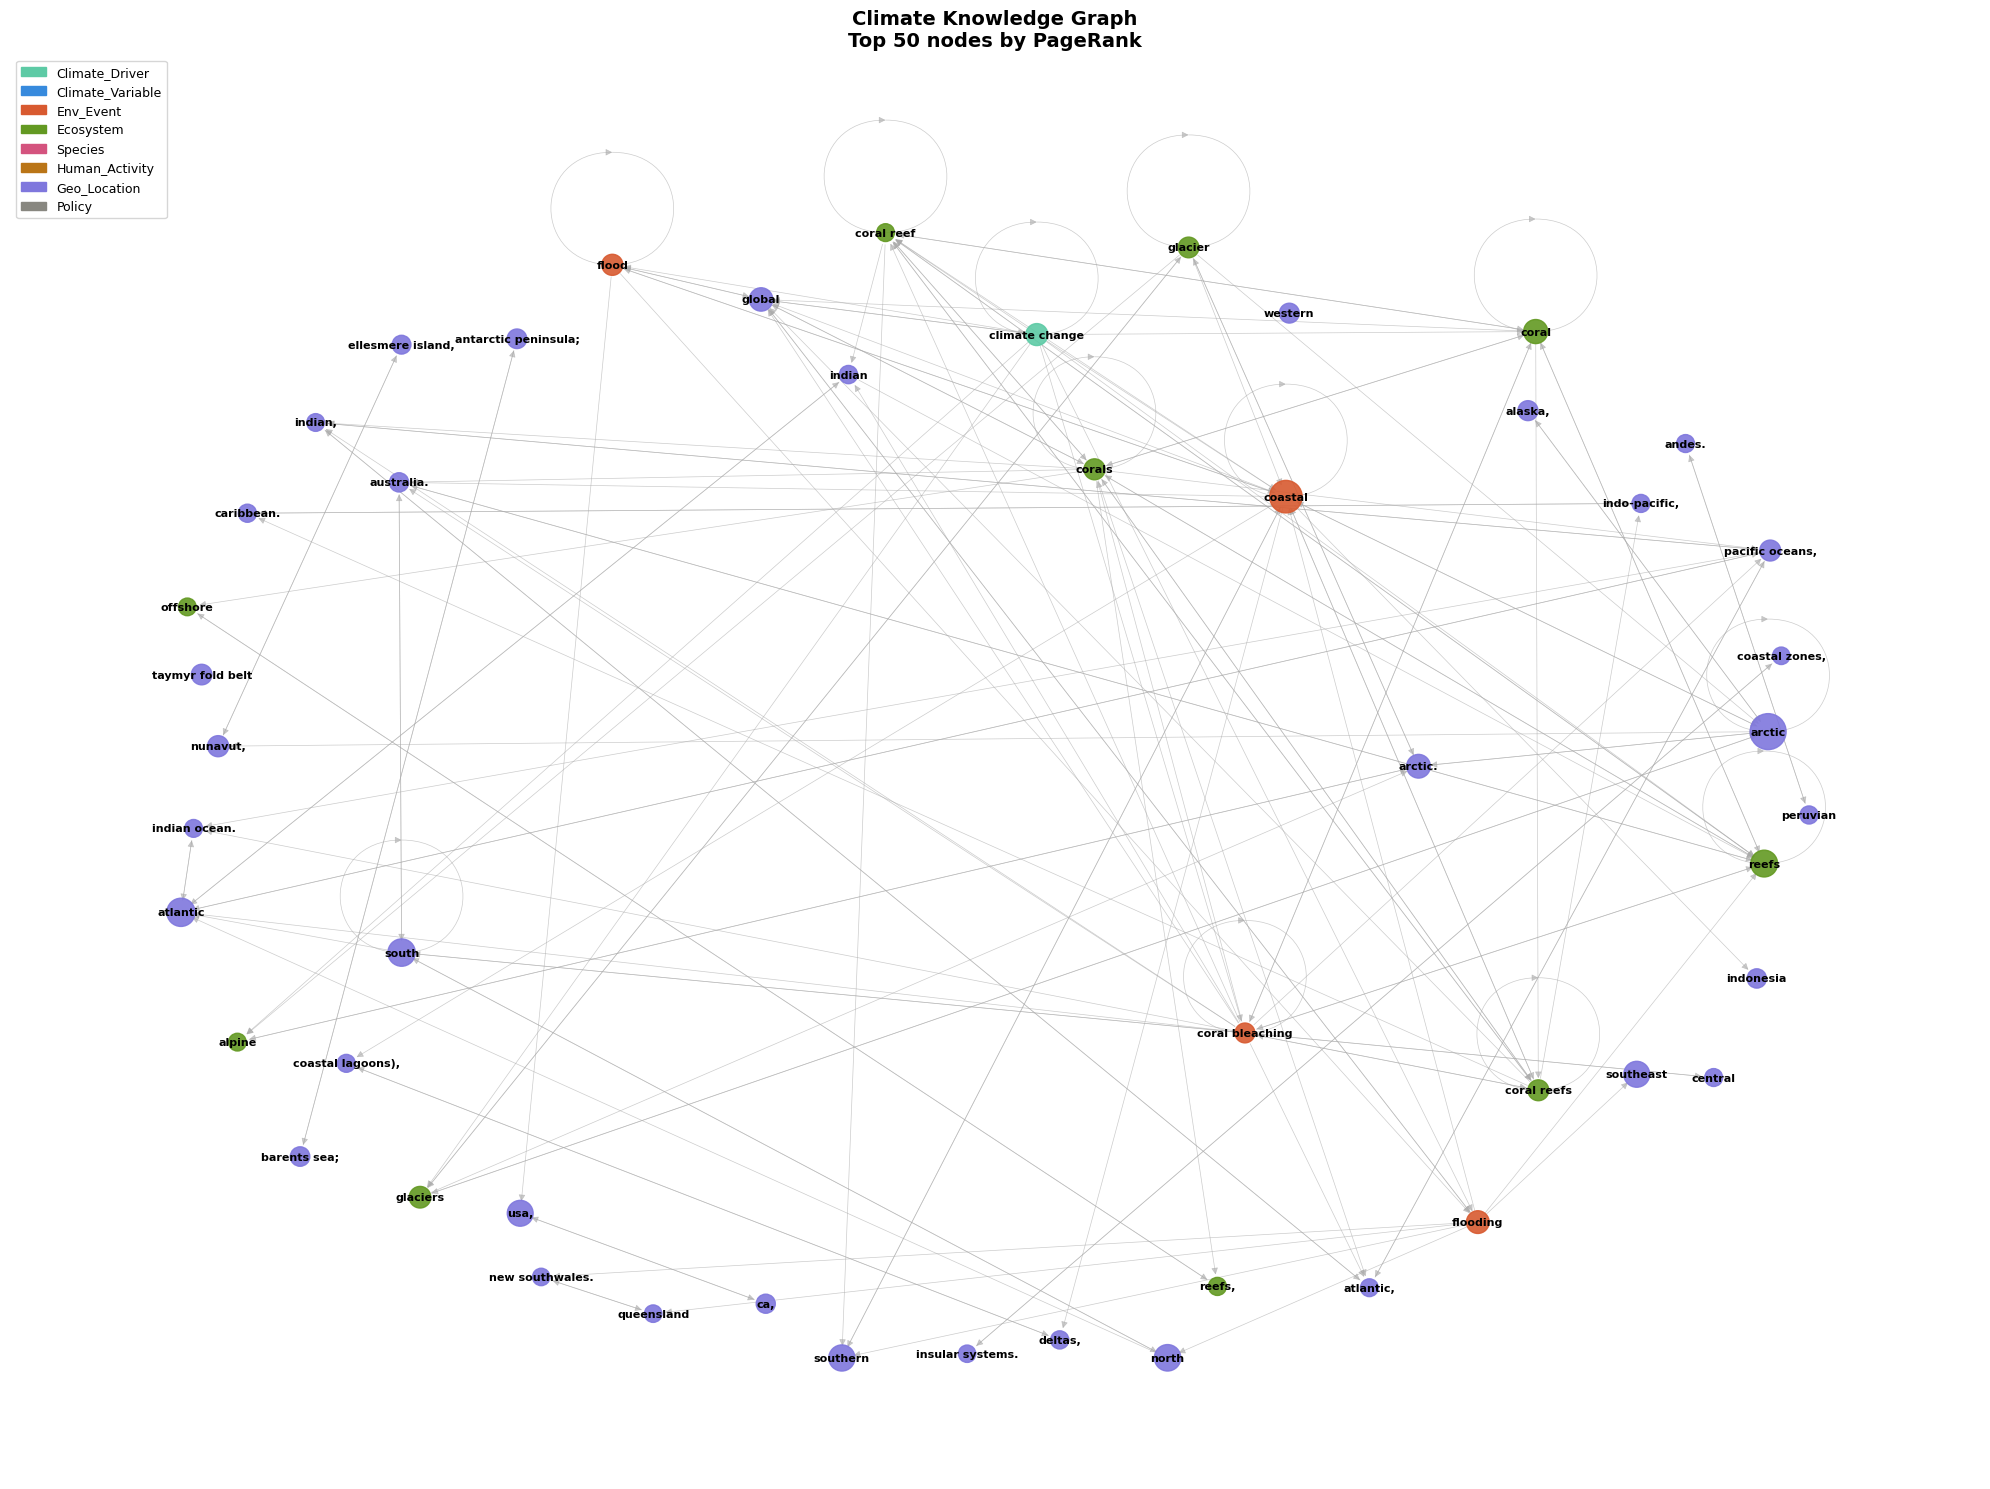

Visualization saved to: D:/Climate_Intelligent_System/outputs/climate_kg_visualization.png


In [23]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Color mapping for entity types
COLOR_MAP = {
    "Climate_Driver": "#5DCAA5",
    "Climate_Variable": "#378ADD",
    "Env_Event": "#D85A30",
    "Ecosystem": "#639922",
    "Species": "#D4537E",
    "Human_Activity": "#BA7517",
    "Geo_Location": "#7F77DD",
    "Policy": "#888780",
    "Unknown": "#CCCCCC"
}

# Get top 50 nodes by pagerank for visualization
top_nodes = sorted(
    pagerank.items(),
    key=lambda x: x[1], reverse=True
)[:50]
top_node_names = [n[0] for n in top_nodes]

# Create subgraph
subgraph = G.subgraph(top_node_names)

# Node colors
node_colors = [
    COLOR_MAP.get(
        subgraph.nodes[n].get("entity_type", "Unknown"),
        "#CCCCCC"
    )
    for n in subgraph.nodes()
]

# Node sizes based on pagerank
node_sizes = [
    pagerank.get(n, 0.001) * 50000
    for n in subgraph.nodes()
]

# Draw
plt.figure(figsize=(20, 15))
pos = nx.spring_layout(subgraph, k=2, seed=42)

nx.draw_networkx_nodes(
    subgraph, pos,
    node_color=node_colors,
    node_size=node_sizes,
    alpha=0.9
)
nx.draw_networkx_labels(
    subgraph, pos,
    font_size=8,
    font_weight="bold"
)
nx.draw_networkx_edges(
    subgraph, pos,
    edge_color="#AAAAAA",
    arrows=True,
    arrowsize=10,
    width=0.5,
    alpha=0.6
)

# Legend
legend_patches = [
    mpatches.Patch(color=color, label=entity_type)
    for entity_type, color in COLOR_MAP.items()
    if entity_type != "Unknown"
]
plt.legend(
    handles=legend_patches,
    loc="upper left",
    fontsize=9
)

plt.title(
    "Climate Knowledge Graph\n"
    "Top 50 nodes by PageRank",
    fontsize=14, fontweight="bold"
)
plt.axis("off")
plt.tight_layout()

# Save
viz_path = "D:/Climate_Intelligent_System/outputs/climate_kg_visualization.png"
os.makedirs(
    "D:/Climate_Intelligent_System/outputs", 
    exist_ok=True
)
plt.savefig(viz_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Visualization saved to: {viz_path}")

In [24]:
def query_what_causes(G, target_entity, max_hops=2):
    """What causes X? — find all causes of a target entity"""
    target = target_entity.lower().strip()
    
    # Find matching nodes
    matches = [n for n in G.nodes() if target in n.lower()]
    if not matches:
        return f"Entity '{target_entity}' not found in graph."
    
    target_node = matches[0]
    results = []
    
    causal_relations = ["causes", "increases", 
                        "contributes_to", "affects"]
    
    # Direct causes (1 hop)
    for predecessor in G.predecessors(target_node):
        edge = G.get_edge_data(predecessor, target_node)
        if edge and edge["relation"] in causal_relations:
            results.append({
                "cause": predecessor,
                "cause_type": G.nodes[predecessor].get(
                    "entity_type", "Unknown"
                ),
                "relation": edge["relation"],
                "confidence": edge["weight"],
                "hops": 1
            })
    
    # 2-hop causes
    if max_hops >= 2:
        for predecessor in list(G.predecessors(target_node)):
            for pre_predecessor in G.predecessors(predecessor):
                edge1 = G.get_edge_data(
                    pre_predecessor, predecessor
                )
                edge2 = G.get_edge_data(
                    predecessor, target_node
                )
                if (edge1 and edge2 and 
                    edge1["relation"] in causal_relations and
                    edge2["relation"] in causal_relations):
                    results.append({
                        "cause": f"{pre_predecessor} → {predecessor}",
                        "cause_type": G.nodes[pre_predecessor].get(
                            "entity_type", "Unknown"
                        ),
                        "relation": f"{edge1['relation']} → {edge2['relation']}",
                        "confidence": (edge1["weight"] + edge2["weight"]) / 2,
                        "hops": 2
                    })
    
    # Sort by confidence
    results.sort(key=lambda x: x["confidence"], reverse=True)
    return results[:10]


def query_impact_of(G, source_entity, max_hops=3):
    """What happens if X increases? — forward impact chain"""
    source = source_entity.lower().strip()
    
    matches = [n for n in G.nodes() if source in n.lower()]
    if not matches:
        return f"Entity '{source_entity}' not found in graph."
    
    source_node = matches[0]
    
    causal_relations = ["causes", "increases",
                        "contributes_to", "affects"]
    
    impacts = []
    visited = {source_node}
    queue = [(source_node, 0, [])]
    
    while queue:
        current, hops, path = queue.pop(0)
        if hops >= max_hops:
            continue
        
        for successor in G.successors(current):
            edge = G.get_edge_data(current, successor)
            if (edge and 
                edge["relation"] in causal_relations and
                successor not in visited):
                
                visited.add(successor)
                new_path = path + [(current, edge["relation"], successor)]
                impacts.append({
                    "impact": successor,
                    "impact_type": G.nodes[successor].get(
                        "entity_type", "Unknown"
                    ),
                    "pathway": new_path,
                    "hops": hops + 1,
                    "confidence": edge["weight"]
                })
                queue.append((successor, hops + 1, new_path))
    
    impacts.sort(key=lambda x: (-x["hops"], -x["confidence"]))
    return impacts[:10]


def run_query(G, query_text):
    """Simple natural language query interface"""
    query_lower = query_text.lower()
    
    print(f"\nQuery: {query_text}")
    print("=" * 60)
    
    # Cause query
    if any(w in query_lower for w in 
           ["what causes", "cause of", "causes of", "why does"]):
        # Extract entity
        for phrase in ["what causes", "cause of", 
                       "causes of", "why does"]:
            if phrase in query_lower:
                entity = query_lower.replace(
                    phrase, ""
                ).strip().rstrip("?")
                break
        
        results = query_what_causes(G, entity)
        if isinstance(results, str):
            print(results)
            return
        
        print(f"Causes of '{entity}':")
        for i, r in enumerate(results, 1):
            print(f"  {i}. [{r['cause_type']}] {r['cause']}")
            print(f"     Relation: {r['relation']} "
                  f"| Confidence: {r['confidence']:.3f} "
                  f"| Hops: {r['hops']}")
    
    # Impact query
    elif any(w in query_lower for w in 
             ["what happens", "impact of", 
              "effects of", "what does"]):
        for phrase in ["what happens if", "impact of",
                       "effects of", "what does"]:
            if phrase in query_lower:
                entity = query_lower.replace(
                    phrase, ""
                ).strip().rstrip("?").replace(
                    "increases", ""
                ).strip()
                break
        
        results = query_impact_of(G, entity)
        if isinstance(results, str):
            print(results)
            return
        
        print(f"Impacts of '{entity}':")
        for i, r in enumerate(results, 1):
            pathway_str = " → ".join(
                [f"{p[0]} --{p[1]}--> {p[2]}" 
                 for p in r["pathway"]]
            )
            print(f"  {i}. [{r['impact_type']}] {r['impact']}")
            print(f"     Path: {pathway_str}")
            print(f"     Confidence: {r['confidence']:.3f} "
                  f"| Hops: {r['hops']}")
    
    else:
        print("Query type not recognized.")
        print("Try: 'What causes X?' or 'What is the impact of X?'")


# Test queries
run_query(G, "What causes coral bleaching?")
run_query(G, "What is the impact of deforestation?")
run_query(G, "What causes sea level rise?")


Query: What causes coral bleaching?
Causes of 'coral bleaching':
  1. [Climate_Driver] sea temperatures
     Relation: causes | Confidence: 0.984 | Hops: 1
  2. [Climate_Driver] global warming
     Relation: causes | Confidence: 0.984 | Hops: 1
  3. [Climate_Driver] global warming → sea temperatures
     Relation: increases → causes | Confidence: 0.984 | Hops: 2
  4. [Climate_Driver] ocean temperature
     Relation: causes | Confidence: 0.983 | Hops: 1
  5. [Climate_Variable] thermal-stress
     Relation: causes | Confidence: 0.983 | Hops: 1
  6. [Climate_Driver] snow accumulation. → global warming
     Relation: contributes_to → causes | Confidence: 0.983 | Hops: 2
  7. [Climate_Driver] carbon emissions, → global warming
     Relation: contributes_to → causes | Confidence: 0.982 | Hops: 2
  8. [Climate_Driver] solar radiation.
     Relation: causes | Confidence: 0.982 | Hops: 1
  9. [Climate_Driver] ocean warming,
     Relation: causes | Confidence: 0.980 | Hops: 1
  10. [Climate_Var

In [25]:
# Fix impact query parsing and test directly
print("Direct impact query test:")
print("=" * 60)

# Test impact of deforestation directly
results = query_impact_of(G, "deforestation")
print(f"\nImpacts of 'deforestation':")
for i, r in enumerate(results, 1):
    pathway_str = " → ".join(
        [f"{p[0]} --{p[1]}--> {p[2]}" 
         for p in r["pathway"]]
    )
    print(f"  {i}. [{r['impact_type']}] {r['impact']}")
    print(f"     Path: {pathway_str}")
    print(f"     Confidence: {r['confidence']:.3f} "
          f"| Hops: {r['hops']}")

# Test impact of climate change
print("\n" + "=" * 60)
results2 = query_impact_of(G, "climate change")
print(f"Impacts of 'climate change':")
for i, r in enumerate(results2, 1):
    pathway_str = " → ".join(
        [f"{p[0]} --{p[1]}--> {p[2]}" 
         for p in r["pathway"]]
    )
    print(f"  {i}. [{r['impact_type']}] {r['impact']}")
    print(f"     Path: {pathway_str}")
    print(f"     Confidence: {r['confidence']:.3f} "
          f"| Hops: {r['hops']}")

Direct impact query test:

Impacts of 'deforestation':
  1. [Ecosystem] sandy beaches
     Path: deforestation --contributes_to--> climate change → climate change --contributes_to--> sea-level rise → sea-level rise --affects--> sandy beaches
     Confidence: 0.990 | Hops: 3
  2. [Ecosystem] coastal forest
     Path: deforestation --contributes_to--> climate change → climate change --contributes_to--> sea-level rise → sea-level rise --affects--> coastal forest
     Confidence: 0.990 | Hops: 3
  3. [Ecosystem] coastal forests
     Path: deforestation --contributes_to--> climate change → climate change --contributes_to--> sea-level rise → sea-level rise --affects--> coastal forests
     Confidence: 0.990 | Hops: 3
  4. [Ecosystem] coastal wetlands
     Path: deforestation --contributes_to--> climate change → climate change --contributes_to--> sea-level rise → sea-level rise --affects--> coastal wetlands
     Confidence: 0.990 | Hops: 3
  5. [Ecosystem] wetlands
     Path: deforestation --